<a href="https://colab.research.google.com/github/rudrarpatel22-lang/bank-marketing-ml/blob/main/notebooks/01_eda_bank_marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Marketing ML Project — Exploratory Data Analysis

**DJS Compute ML Superset — Task 1**

This notebook explores the UCI Bank Marketing dataset before supervised modelling.

### Project objective
The bank can contact only **500 customers**. The final supervised model must rank historical records by predicted subscription probability using information available **before the call**.

> **Important:** `duration` is excluded from the realistic predictive feature set because it is only known after the call.

This notebook covers dataset structure, data quality, target balance, categorical/numerical variables, unknown values, `pdays = 999`, feature availability, temporal ordering, and relevant exploratory relationships.


## 1. Import Libraries


In [35]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")


## 2. Load the Dataset

The assignment specifies the full `bank-additional-full.csv` file with **41,188 records and 20 input fields plus target `y`**.

The local copy has non-standard CSV quoting, so the semicolon separator is read with quoting disabled and the literal quotation marks are removed afterward.


In [36]:
df = pd.read_csv(
    "bank-additional-full.csv",
    sep=";",
    quoting=csv.QUOTE_NONE
)

df = df.map(
    lambda x: x.strip('"') if isinstance(x, str) else x
)
df.columns = df.columns.str.strip('"')

print("Shape:", df.shape)
display(df.head())


Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Dataset Overview


### Dataset Information


In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  object 
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Numerical Summary


In [38]:
display(df.describe())


,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Column Names


In [39]:
print(df.columns.tolist())


['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


## 4. Basic Data Cleaning

`age` represents a numerical quantity but can load as `object` because of the unusual quotation structure of this local CSV copy. Convert it explicitly after confirming the values are numeric.


In [40]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

print(df[["age"]].dtypes)
print("Missing ages after conversion:", df["age"].isna().sum())


age    int64
dtype: object
Missing ages after conversion: 0


## 5. Missing Values and Unknown Categories


### Actual Missing Values


In [41]:
missing_counts = df.isna().sum()

if missing_counts.sum() == 0:
    print("No actual NaN values found.")
else:
    display(missing_counts[missing_counts > 0].sort_values(ascending=False))


No actual NaN values found.


### Literal `unknown` Values


In [42]:
unknown_counts = (df == "unknown").sum()

display(
    unknown_counts[unknown_counts > 0]
    .sort_values(ascending=False)
)


,0
default,8597
education,1731
housing,990
loan,990
job,330
marital,80


**Write your interpretation here:** Which columns contain `unknown`, how frequent are they, and how should they be handled during modelling?


## 6. Duplicate Records


In [43]:
duplicate_count = df.duplicated().sum()
print("Number of exact duplicate rows:", duplicate_count)


Number of exact duplicate rows: 12


## 7. Target Distribution

The target is whether the contacted client subscribed to a term deposit.

Because the target is imbalanced, accuracy alone will not be sufficient for the modelling task.


Counts:


,count
y,
no,36548
yes,4640


Proportions:


,proportion
y,
no,0.887346
yes,0.112654


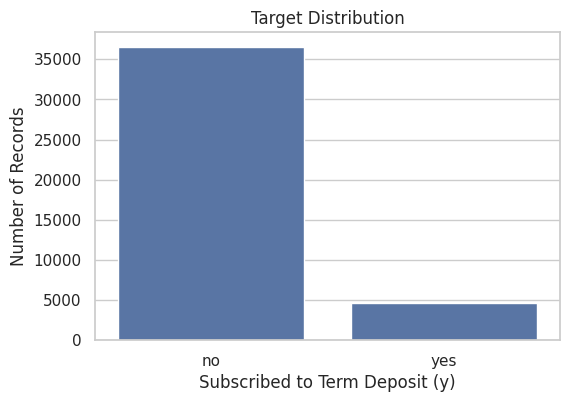

In [44]:
target_counts = df["y"].value_counts()
target_proportions = df["y"].value_counts(normalize=True)

print("Counts:")
display(target_counts)

print("Proportions:")
display(target_proportions)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Distribution")
plt.xlabel("Subscribed to Term Deposit (y)")
plt.ylabel("Number of Records")
plt.show()


## 8. Numerical and Categorical Features


In [45]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numeric_cols)


Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

Numerical columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


### Categorical Value Counts


In [46]:
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).head(15))



--- job ---
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

--- marital ---
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

--- education ---
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

--- default ---
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

--- housing ---
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

--- loan ---
loan
no         33950
yes         6248
unknown      9

## 9. Investigate `pdays = 999`

`pdays = 999` is a special code indicating that the client was not previously contacted in a previous campaign. It should not be treated as an ordinary 999-day interval.


In [47]:
pdays_999_count = (df["pdays"] == 999).sum()
pdays_999_pct = (df["pdays"] == 999).mean() * 100

print(f"Records with pdays = 999: {pdays_999_count:,}")
print(f"Percentage with pdays = 999: {pdays_999_pct:.2f}%")

display(
    df.groupby(df["pdays"] == 999)["y"]
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)


Records with pdays = 999: 39,673
Percentage with pdays = 999: 96.32%


,pdays,y,proportion
0,False,yes,0.638284
1,False,no,0.361716
2,True,no,0.907418
3,True,yes,0.092582


### Previous Contact and `pdays`


In [48]:
display(
    pd.crosstab(
        df["pdays"] == 999,
        df["previous"],
        normalize="index"
    ).round(3)
)


previous,0,1,2,3,4,5,6,7
pdays,,,,,,,,
False,0.000,0.571,0.267,0.110,0.038,0.011,0.003,0.001
True,0.896,0.093,0.009,0.001,0.000,0.000,0.000,0.000


## 10. Feature Availability Audit

The bank chooses whom to call **before the current call begins**.

Therefore `duration` is not available at the decision point and must be excluded from the realistic predictive model. `y` is the historical outcome and is never an input.

The final modelling notebook will explicitly define the predictor set after this audit.


In [49]:
feature_audit = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "decision_point_status": [
        "POST-CALL — EXCLUDE" if col == "duration"
        else "TARGET — EXCLUDE" if col == "y"
        else "AVAILABLE/REVIEW"
        for col in df.columns
    ]
})

display(feature_audit)


,feature,dtype,decision_point_status
0,age,int64,AVAILABLE/REVIEW
1,job,object,AVAILABLE/REVIEW
2,marital,object,AVAILABLE/REVIEW
3,education,object,AVAILABLE/REVIEW
4,default,object,AVAILABLE/REVIEW
5,housing,object,AVAILABLE/REVIEW
6,loan,object,AVAILABLE/REVIEW
7,contact,object,AVAILABLE/REVIEW
8,month,object,AVAILABLE/REVIEW
9,day_of_week,object,AVAILABLE/REVIEW


### Explicit exclusion

The modelling notebook will remove:

```python
"duration"
```

and:

```python
"y"
```

from the predictor set.


## 11. Temporal Ordering

The assignment states that the full file is ordered by date. The final modelling design will therefore reserve later records as a final holdout and use earlier records for training/tuning.


In [50]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nMonth distribution:")
display(df["month"].value_counts())


First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



Last 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,239,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no



Month distribution:


,count
month,
may,13769
jul,7174
aug,6178
jun,5318
nov,4101
apr,2632
oct,718
sep,570
mar,546


## 12. Numerical Feature Distributions


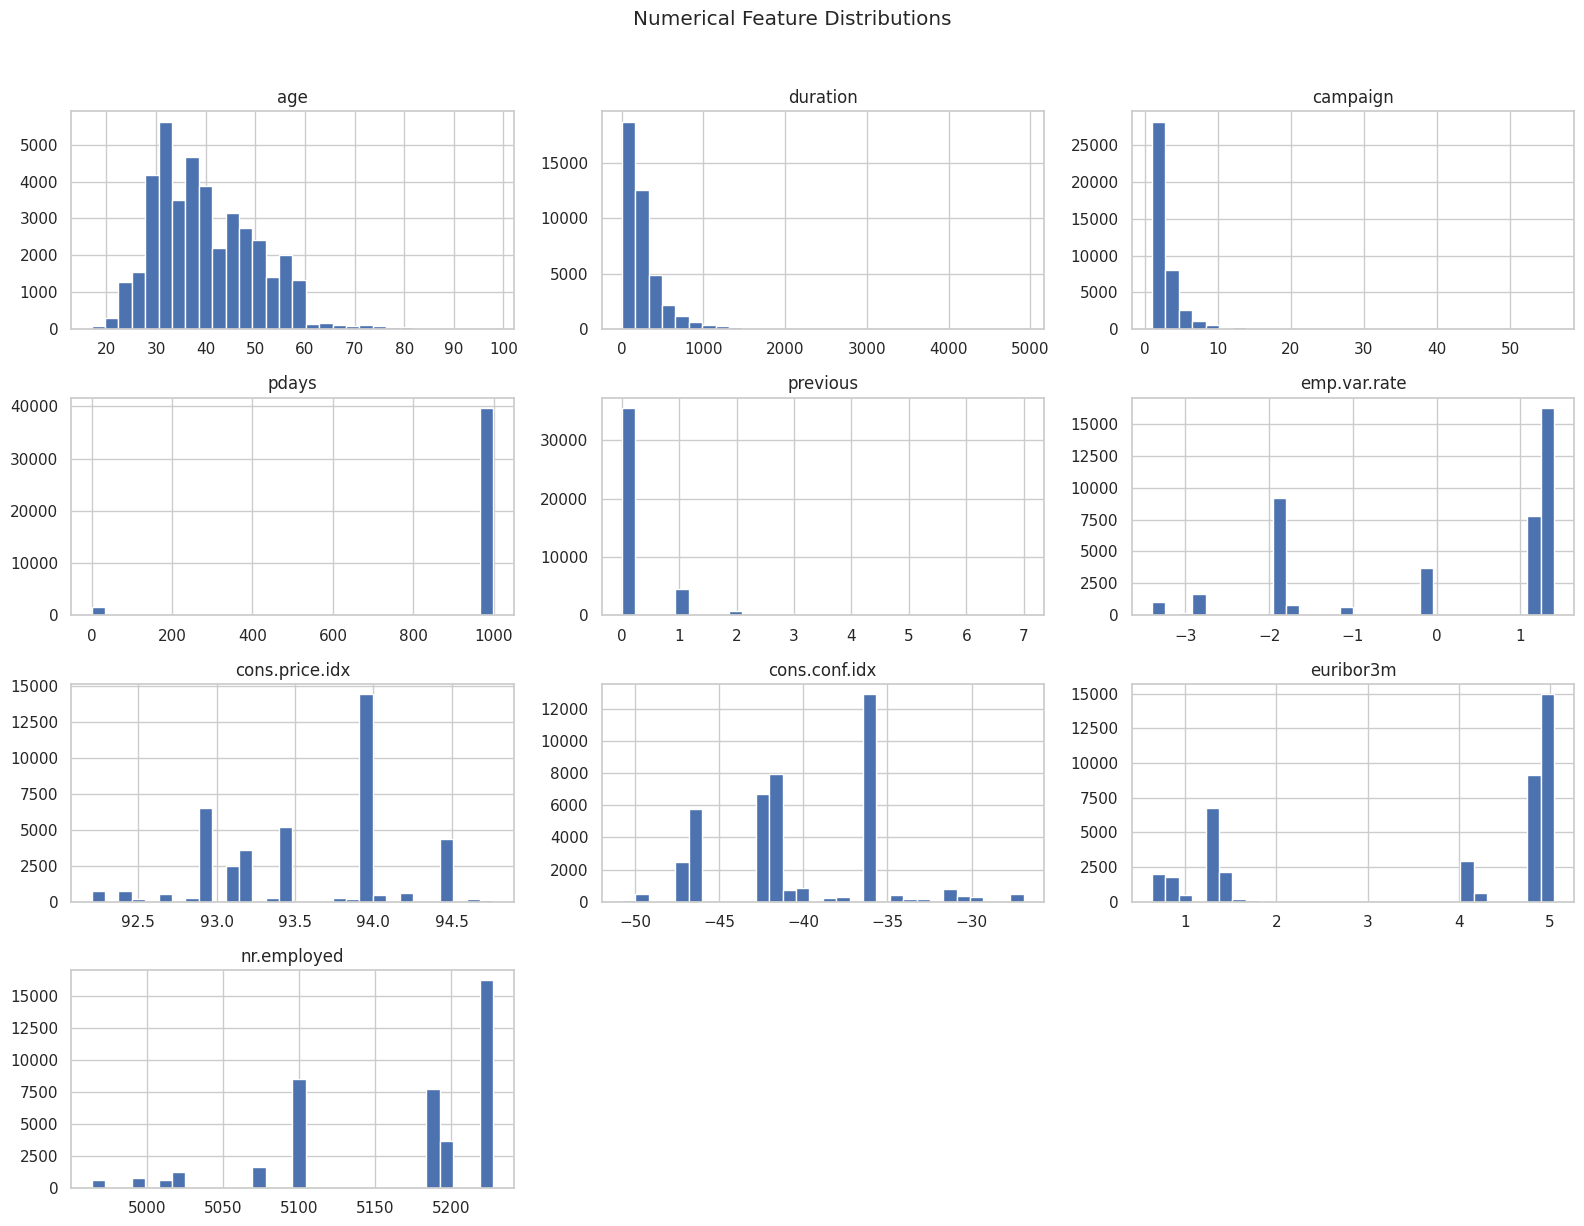

In [51]:
eda_numeric_cols = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]

df[eda_numeric_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


## 13. Selected Relationships with the Target


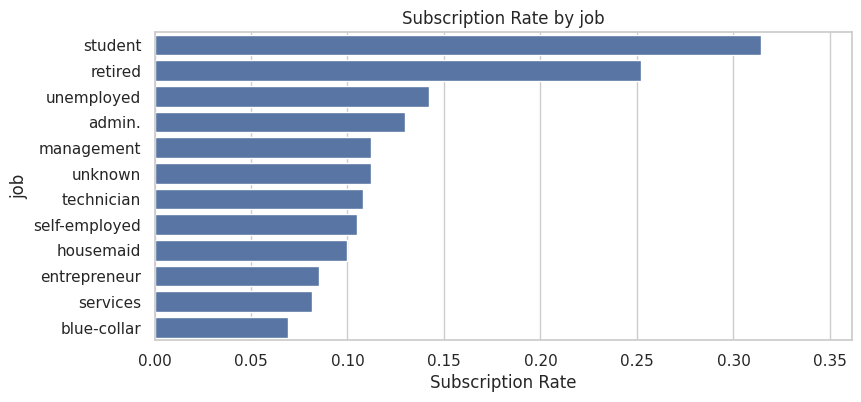

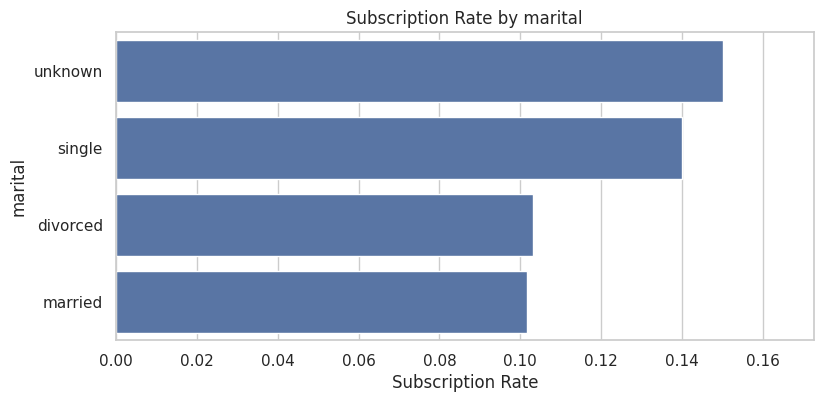

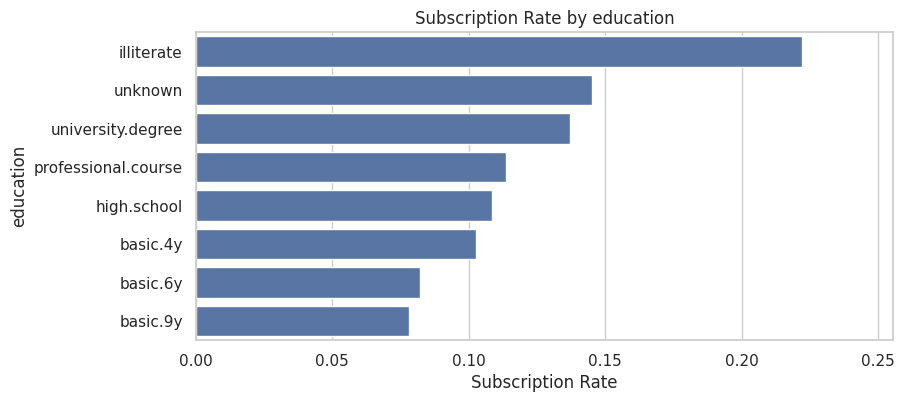

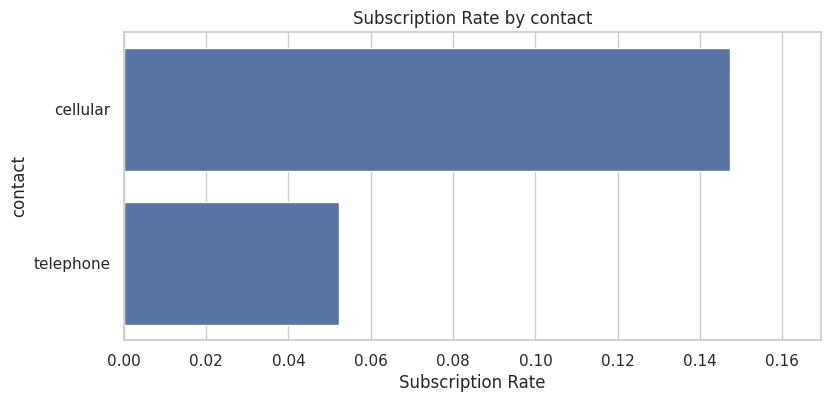

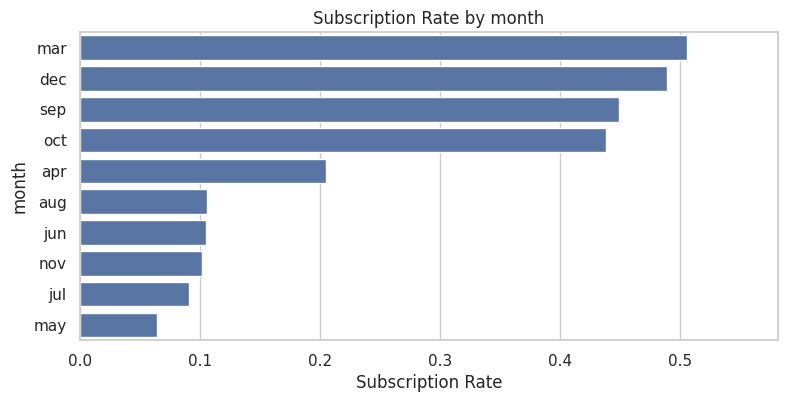

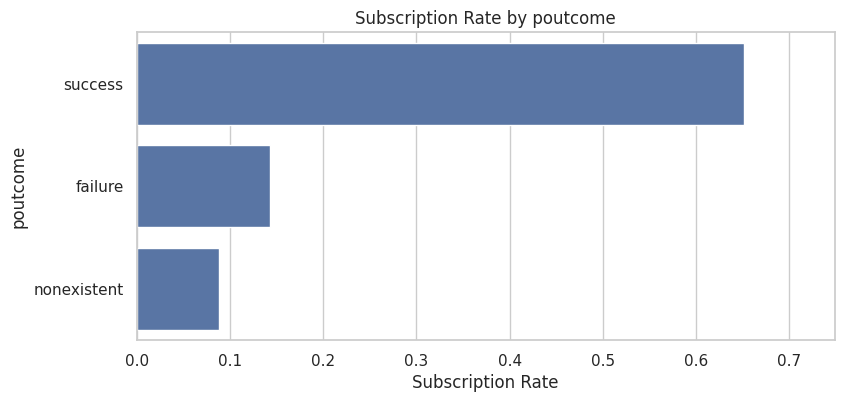

In [52]:
selected_cats = ["job", "marital", "education", "contact", "month", "poutcome"]

for col in selected_cats:
    rate = (
        df.groupby(col)["y"]
          .apply(lambda s: (s == "yes").mean())
          .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 4))
    sns.barplot(x=rate.values, y=rate.index)
    plt.title(f"Subscription Rate by {col}")
    plt.xlabel("Subscription Rate")
    plt.ylabel(col)
    plt.xlim(0, max(0.1, rate.max() * 1.15))
    plt.show()


### Age and Subscription


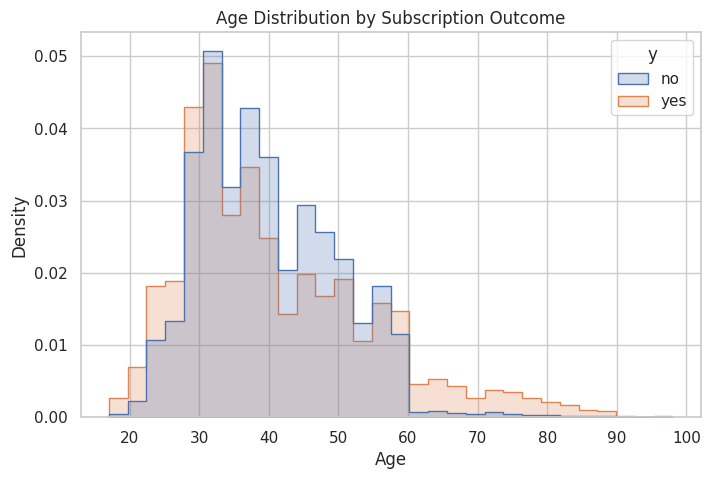

In [53]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="age",
    hue="y",
    bins=30,
    element="step",
    stat="density",
    common_norm=False
)
plt.title("Age Distribution by Subscription Outcome")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()


## 14. Correlation Among Numerical Features


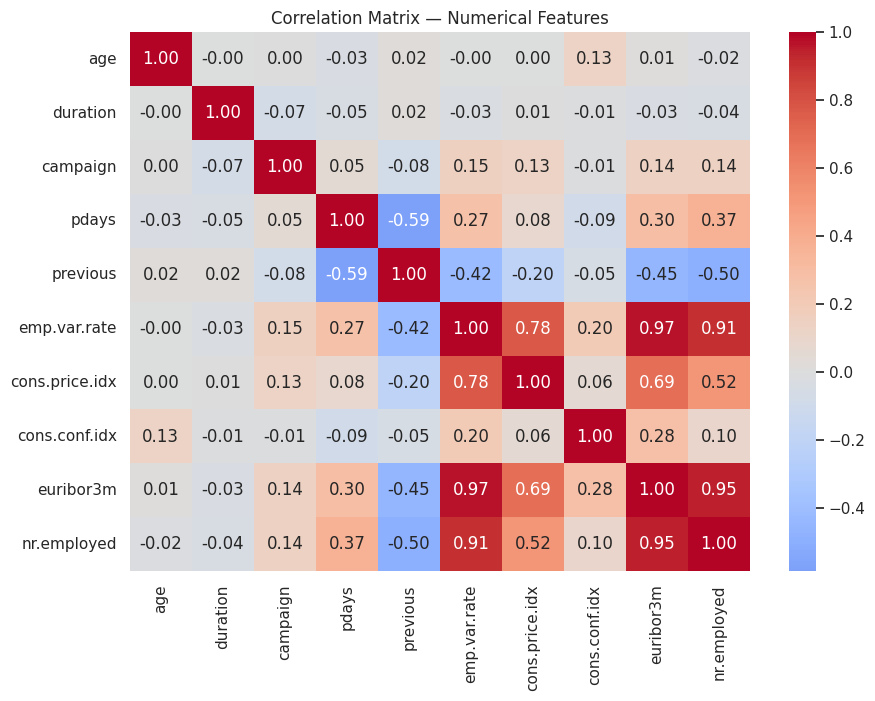

In [54]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[eda_numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Matrix — Numerical Features")
plt.show()
